#  Weather Prediction ML — Full Multi-Model Pipeline
---
This notebook runs the complete pipeline:
- **Steps 1–5**: Install packages, clone repo, upload data, EDA & cleaning
- **Pipeline Toggle**: Choose baseline vs advanced ML pipeline
- **Steps 6–7**: Feature engineering + XGBoost / LightGBM training
- **Model Flags**: Independently enable/disable LSTM, ARIMA, and Ensemble
- **Step 8**: LSTM (Bidirectional + Attention)
- **Step 9**: AR / ARIMA / SARIMA (statistical models)
- **Step 10**: Final Ensemble (weighted average of all models)
- **Step 11**: Push models to GitHub
- **Step 12**: Launch Streamlit app


##Fix NumPy & Install Dependencies
> **After this cell finishes, the runtime will restart automatically. That is normal.**

In [ ]:
# STEP 1: Install correct NumPy first, then everything else
import subprocess, sys

print(' Installing numpy 1.26.4 first...')
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'numpy==1.26.4', '--force-reinstall', '-q'], check=True)

print(' Installing all other packages...')
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'pandas==2.2.2', 'scikit-learn==1.4.2',
                'xgboost==2.0.3', 'lightgbm==4.3.0',
                'shap==0.45.1', 'matplotlib==3.8.4',
                'seaborn==0.13.2', 'plotly==5.20.0',
                'joblib==1.4.0', 'streamlit==1.33.0',
                'pyngrok==7.0.5', '-q'], check=True)

print('\n All packages installed. Restarting runtime now...')
import os
os.kill(os.getpid(), 9)
print(' Installing deep learning + time-series packages...')
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'tensorflow', 'statsmodels', '-q'], check=True)
print(' All packages installed.')


 Installing numpy 1.26.4 first...
 Installing all other packages...


## STEP 2 — Verify Packages
> **Runtime just restarted. Run this cell first to confirm versions.**

In [1]:
# STEP 2: Verify all versions are correct
import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb
import lightgbm as lgb

print('Package versions:')
print(f'  numpy      : {np.__version__}   (need 1.26.4)')
print(f'  pandas     : {pd.__version__}   (need 2.2.2)')
print(f'  sklearn    : {sklearn.__version__}   (need 1.4.2)')
print(f'  xgboost    : {xgb.__version__}   (need 2.0.3)')
print(f'  lightgbm   : {lgb.__version__}   (need 4.3.0)')

assert np.__version__ == '1.26.4', 'Wrong numpy! Re-run Step 1.'
print('\n All versions correct. Proceed to Step 3.')

Package versions:
  numpy      : 1.26.4   (need 1.26.4)
  pandas     : 2.2.2   (need 2.2.2)
  sklearn    : 1.4.2   (need 1.4.2)
  xgboost    : 2.0.3   (need 2.0.3)
  lightgbm   : 4.3.0   (need 4.3.0)

 All versions correct. Proceed to Step 3.


##STEP 3 — Clone GitHub Repo

In [2]:
# STEP 3: Clone repo and move into it
import os

repo_url = 'https://github.com/siddharth277/Ensemble-weather-prediction'
repo_dir = '/content/Ensemble-weather-prediction'

if os.path.exists(repo_dir):
    print('Repo already exists, pulling latest changes...')
    os.chdir(repo_dir)
    os.system('git pull')
else:
    os.system(f'git clone {repo_url}')
    os.chdir(repo_dir)

print(f'\nWorking directory: {os.getcwd()}')
print('\nFolder contents:')
for item in sorted(os.listdir('.')):
    print(f'  {item}')


Working directory: /content/Ensemble-weather-prediction

Folder contents:
  .git
  .gitignore
  README.md
  RUN_IN_COLAB.ipynb
  app
  data
  models
  notebooks
  reports
  requirements.txt
  src


##STEP 4 — Upload Dataset
> Upload **Train.csv** and **Test.csv** when the file picker appears.

In [3]:
# STEP 4: Upload Train.csv and Test.csv
import os
from google.colab import files

os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('reports', exist_ok=True)

# Check if already uploaded
train_exists = os.path.exists('data/raw/Train.csv')
test_exists  = os.path.exists('data/raw/Test.csv')

if train_exists and test_exists:
    print('Train.csv and Test.csv already present. Skipping upload.')
else:
    print('Please upload Train.csv and Test.csv...')
    uploaded = files.upload()
    for fname in uploaded:
        dest = f'data/raw/{fname}'
        os.rename(fname, dest)
        print(f'  Moved {fname} → {dest}')

import pandas as pd
train = pd.read_csv('data/raw/Train.csv')
test  = pd.read_csv('data/raw/Test.csv')
print(f'\nTrain: {train.shape}, Test: {test.shape}')
print(train.head(3))

Please upload Train.csv and Test.csv...


Saving Train.csv to Train.csv
Saving Test.csv to Test.csv
  Moved Train.csv → data/raw/Train.csv
  Moved Test.csv → data/raw/Test.csv

Train: (1462, 5), Test: (114, 5)
         date   meantemp  humidity  wind_speed  meanpressure
0  2013-01-01  10.000000      84.5    0.000000   1015.666667
1  2013-01-02   7.400000      92.0    2.980000   1017.800000
2  2013-01-03   7.166667      87.0    4.633333   1018.666667


##STEP 5 — EDA & Data Cleaning

Libraries loaded successfully
Train shape : (1462, 5)
Test shape  : (114, 5)
date            datetime64[ns]
meantemp               float64
humidity               float64
wind_speed             float64
meanpressure           float64
dtype: object

Basic stats:
=== MISSING VALUES ===
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Total missing: 0
Duplicate rows: 0


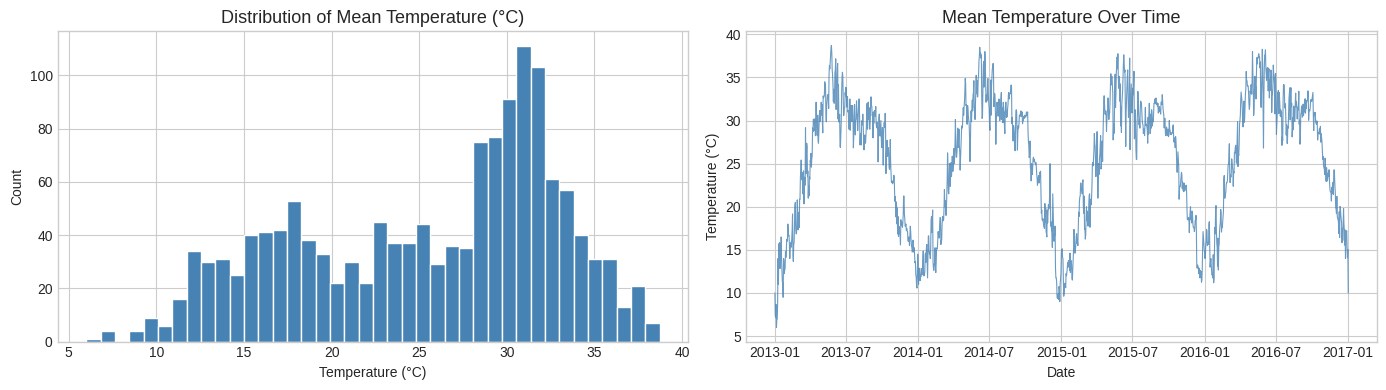

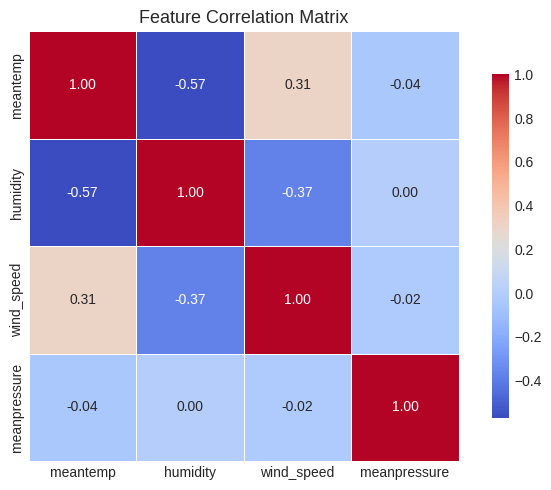

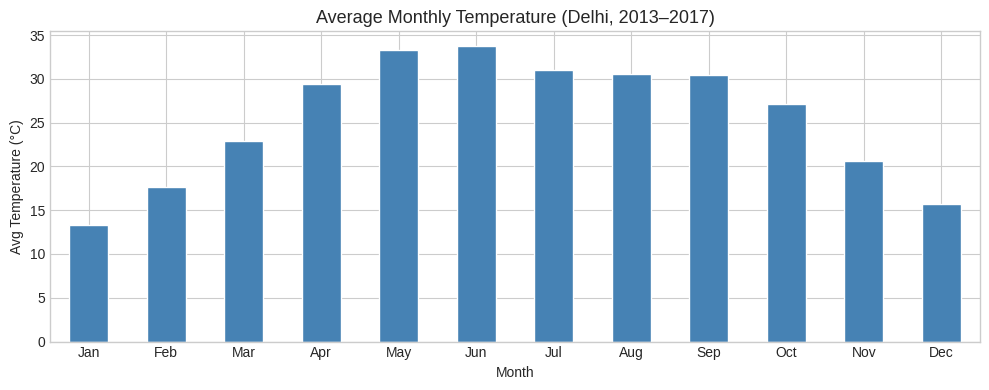

=== OUTLIER DETECTION ===
meantemp        | Q1=   18.86 Q3=   31.31 | Range=[0.18, 49.98] | Outliers=0
humidity        | Q1=   50.38 Q3=   72.22 | Range=[17.61, 104.98] | Outliers=2
wind_speed      | Q1=    3.48 Q3=    9.24 | Range=[-5.17, 17.88] | Outliers=30
meanpressure    | Q1= 1001.58 Q3= 1014.94 | Range=[981.53, 1034.99] | Outliers=9


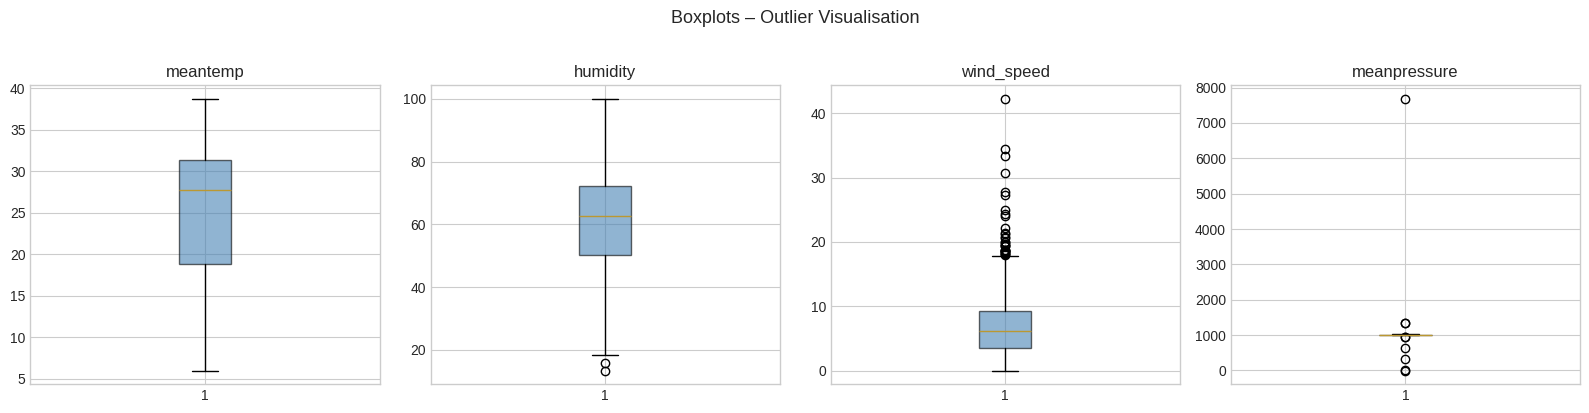

Fixing 7 bad pressure rows
Fixing 0 negative wind rows
Capping 0 humidity rows > 100
Fixing 1 bad pressure rows
Fixing 0 negative wind rows
Capping 0 humidity rows > 100

=== BEFORE vs AFTER CLEANING ===

meanpressure  BEFORE: min=-3.04, max=7679.33
meanpressure  AFTER : min=938.07, max=1023.00

Missing values BEFORE: 0
Missing values AFTER : 0

✅ Cleaned data saved to data/processed/

EDA and Cleaning complete!


<Figure size 640x480 with 0 Axes>

In [4]:
# STEP 5: Run EDA and Cleaning
import os
os.chdir('/content/Ensemble-weather-prediction')
%run notebooks/02_eda_cleaning.py
print('\nEDA and Cleaning complete!')

## PIPELINE TOGGLE & MODEL FLAGS
> **Baseline vs Advanced**: controls which feature engineering + ML training runs (Steps 6–7).
>
> **Model flags**: independently enable/disable LSTM, ARIMA/SARIMA, and Ensemble.
>
> Run this cell **before** any of Steps 6–10.

In [5]:
# ══════════════════════════════════════════════════════════════
# PIPELINE TOGGLE
# ══════════════════════════════════════════════════════════════
# Baseline vs Advanced ML pipeline (Steps 6 & 7)
RUN_BASELINE  = False  # True  = 3 raw features (baseline)
                       # False = 40+ engineered features (advanced)

# Individual model flags (Steps 8, 9, 10)
RUN_LSTM      = True   # Bidirectional LSTM + Multi-Head Attention
RUN_ARIMA     = True   # AR + ARIMA + SARIMA (statistical walk-forward)
RUN_ENSEMBLE  = True   # Weighted average of all model predictions

# ── Derive script paths from toggle ──────────────────────────────
pipeline_name = 'BASELINE (3 raw features)' if RUN_BASELINE else 'ADVANCED (40+ features)'
fe_script     = 'notebooks/03_feature_engineering_baseline.py' if RUN_BASELINE \
                else 'notebooks/03_feature_engineering.py'
train_script  = 'notebooks/04_model_train_baseline.py' if RUN_BASELINE \
                else 'notebooks/04_model_train_evaluate.py'

print('=' * 60)
print(f'  ML Pipeline   : {pipeline_name}')
print(f'  RUN_LSTM      : {RUN_LSTM}')
print(f'  RUN_ARIMA     : {RUN_ARIMA}')
print(f'  RUN_ENSEMBLE  : {RUN_ENSEMBLE}')
print('=' * 60)
print()
print('  Execution order:')
print(f'    Step 6  → {fe_script}')
print(f'    Step 7  → {train_script}')
if RUN_LSTM:
    print( '    Step 8  → notebooks/05_lstm_model.py')
if RUN_ARIMA:
    print( '    Step 9  → notebooks/05_arima_model.py')
if RUN_ENSEMBLE:
    print( '    Step 10 → notebooks/06_ensemble.py')
print('  Run each step cell in order below.')


  ML Pipeline   : ADVANCED (40+ features)
  RUN_LSTM      : True
  RUN_ARIMA     : True
  RUN_ENSEMBLE  : True

  Execution order:
    Step 6  → notebooks/03_feature_engineering.py
    Step 7  → notebooks/04_model_train_evaluate.py
    Step 8  → notebooks/05_lstm_model.py
    Step 9  → notebooks/05_arima_model.py
    Step 10 → notebooks/06_ensemble.py
  Run each step cell in order below.


## STEP 6 — Feature Engineering
> Runs the feature engineering script selected by the **Pipeline Toggle** above.
>
> - **Baseline**: loads `train_clean.csv`, keeps 3 raw features, saves `train_baseline.csv`
> - **Advanced**: loads `train_clean.csv`, engineers 40+ features, saves `train_features.csv`

Running ADVANCED (40+ features) feature engineering...
Script: notebooks/03_feature_engineering.py

Train: (1462, 6), Test: (114, 5)

Features before engineering: 6
Features after  engineering: 46

New feature columns:
  year
  day
  day_of_year
  day_of_week
  season
  month_sin
  month_cos
  doy_sin
  doy_cos
  temp_lag1
  humidity_lag1
  pressure_lag1
  wind_lag1
  temp_lag2
  humidity_lag2
  pressure_lag2
  wind_lag2
  temp_lag3
  humidity_lag3
  pressure_lag3
  wind_lag3
  temp_lag7
  humidity_lag7
  pressure_lag7
  wind_lag7
  temp_roll_mean3
  temp_roll_std3
  hum_roll_mean3
  temp_roll_mean7
  temp_roll_std7
  hum_roll_mean7
  temp_roll_mean14
  temp_roll_std14
  hum_roll_mean14
  temp_ewm7
  temp_ewm14
  heat_index
  pressure_delta
  temp_delta
  wind_chill

X_train shape : (1448, 43)
X_test  shape : (114, 43)
y_train stats : mean=25.64, std=7.22


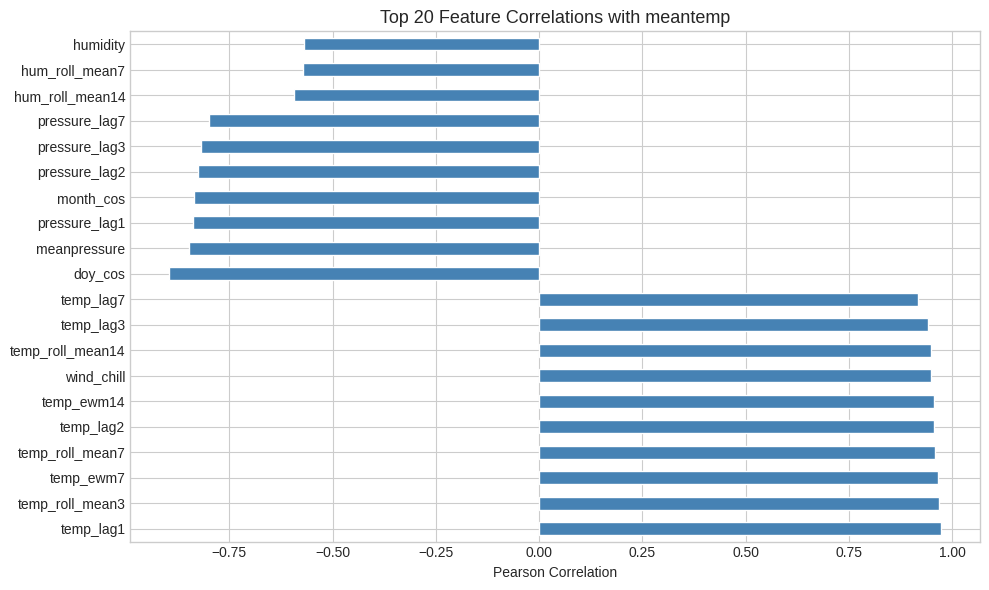


 Feature-engineered data saved!
   Features list saved to models/feature_meta.pkl

  Feature Engineering complete! (Pipeline: ADVANCED (40+ features))


<Figure size 640x480 with 0 Axes>

In [6]:
# STEP 6: Feature Engineering (pipeline-aware)
import os
os.chdir('/content/Ensemble-weather-prediction')

print(f'Running {pipeline_name} feature engineering...')
print(f'Script: {fe_script}\n')

%run $fe_script

print(f'\n  Feature Engineering complete! (Pipeline: {pipeline_name})')


## STEP 7 — Model Training & Evaluation
> Trains XGBoost and LightGBM using the pipeline selected above.
>
> - **Baseline**: ~1–2 minutes. Uses 3 raw features.
> - **Advanced**: ~3–5 minutes. Uses 40+ engineered features.
>
> After running, compare the RMSE and R² between pipelines to see the impact of feature engineering!

Training models for ADVANCED (40+ features) pipeline...
Script: notebooks/04_model_train_evaluate.py

X_train: (1448, 43), X_test: (114, 43)
Test labels available: True
[0]	validation_0-rmse:6.93287
[50]	validation_0-rmse:1.01931
[100]	validation_0-rmse:0.56804
[150]	validation_0-rmse:0.51501
[200]	validation_0-rmse:0.50114
[250]	validation_0-rmse:0.49477
[300]	validation_0-rmse:0.49066
[350]	validation_0-rmse:0.48759
[400]	validation_0-rmse:0.48533
[450]	validation_0-rmse:0.48398
[499]	validation_0-rmse:0.48283
────────────────────────────────────────
Model : XGBoost
RMSE  : 0.4827 °C
MAE   : 0.3471 °C
MAPE  : 1.22%
R²    : 0.9927
────────────────────────────────────────
────────────────────────────────────────
Model : XGBoost [TEST]
RMSE  : 0.4938 °C
MAE   : 0.3462 °C
MAPE  : 1.74%
R²    : 0.9939
────────────────────────────────────────
  ↑ XGBoost evaluated on HELD-OUT TEST SET
[50]	valid_0's l2: 0.992297
[100]	valid_0's l2: 0.26707
[150]	valid_0's l2: 0.222223
[200]	valid_0's l2: 0

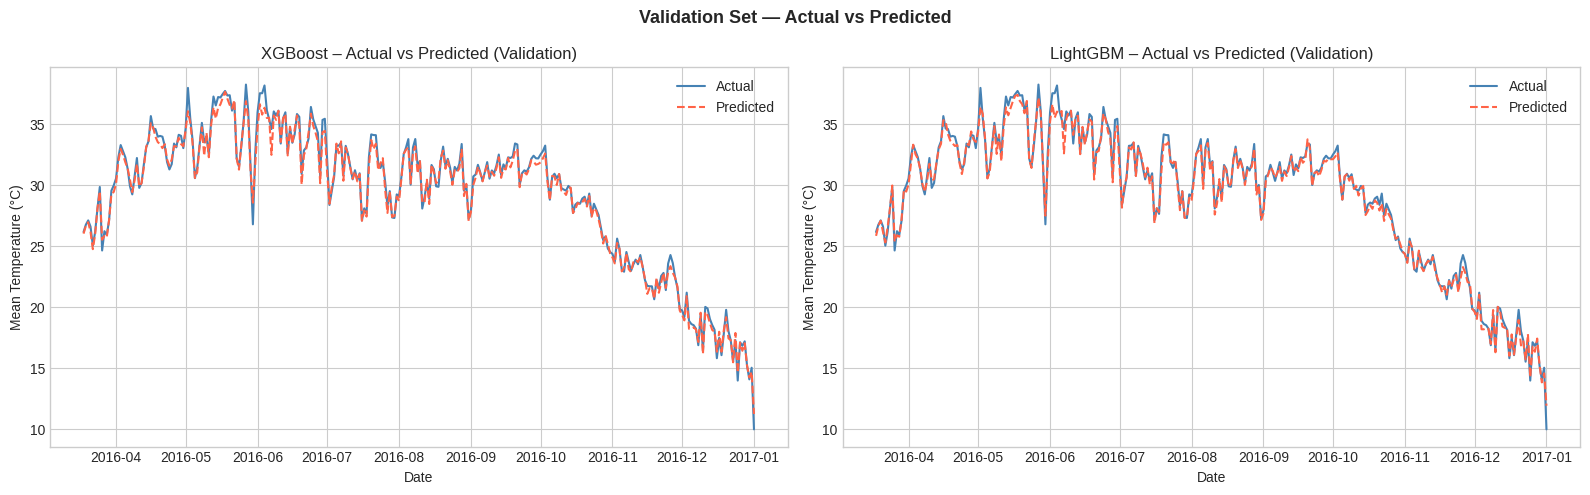

  Saved -> reports/actual_vs_predicted_val.png


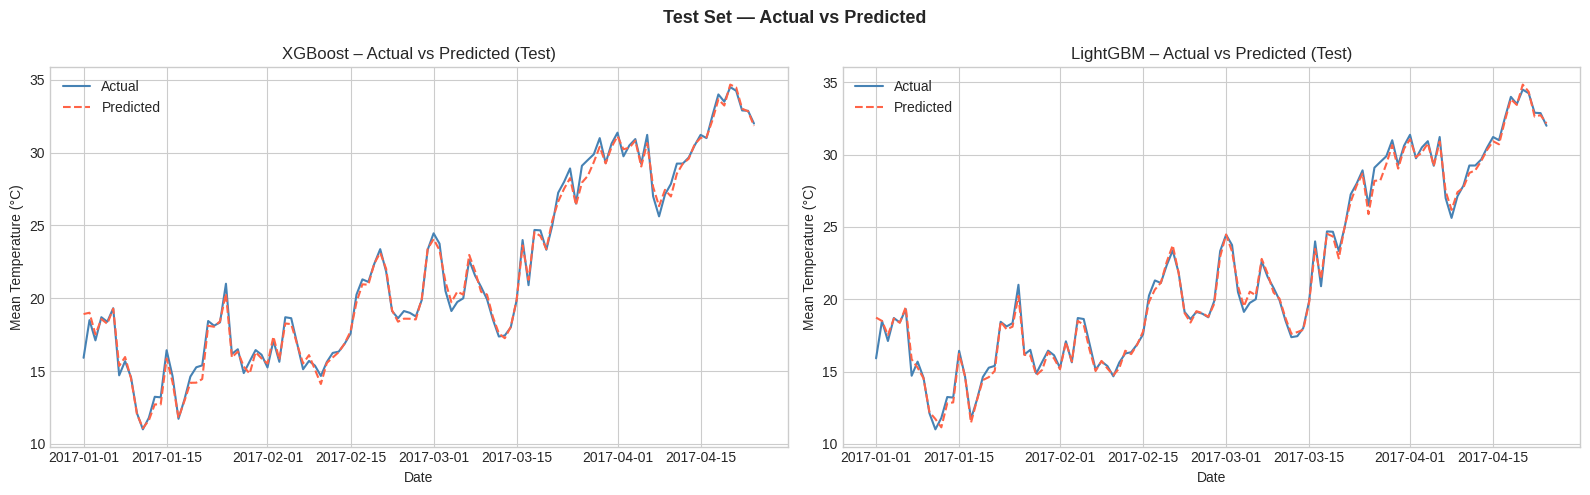

  Saved -> reports/actual_vs_predicted_test.png

=== VALIDATION MODEL COMPARISON ===
   model     RMSE      MAE     MAPE       R2
 XGBoost 0.482723 0.347053 1.218357 0.992746
LightGBM 0.454529 0.320686 1.150712 0.993569

=== TEST SET MODEL COMPARISON ===
          model     RMSE      MAE     MAPE       R2
 XGBoost [TEST] 0.493778 0.346180 1.740056 0.993919
LightGBM [TEST] 0.444324 0.295922 1.498745 0.995076


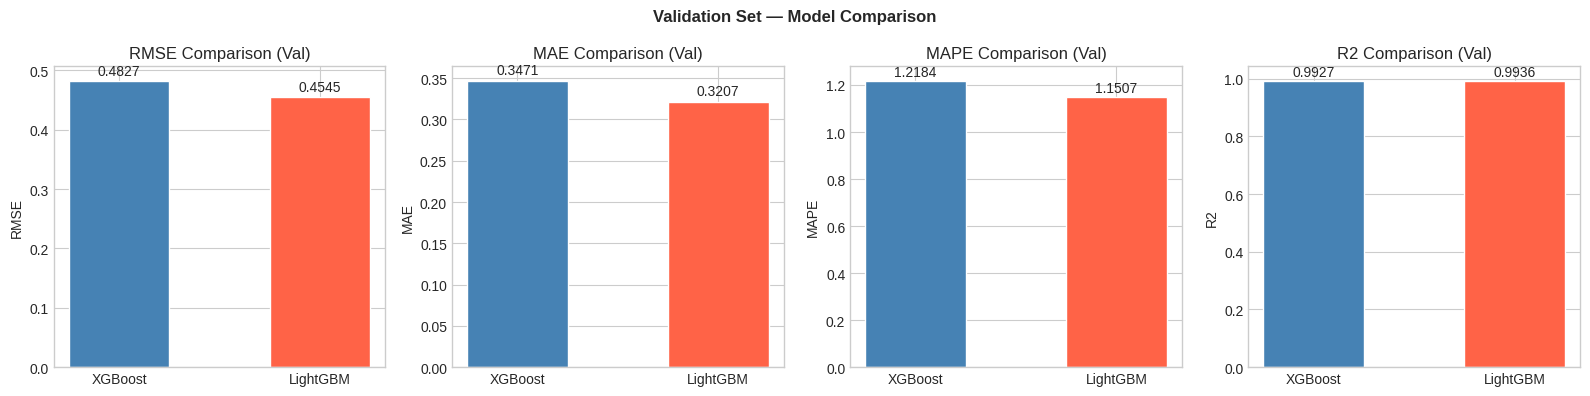

  Saved -> reports/model_comparison_val.png


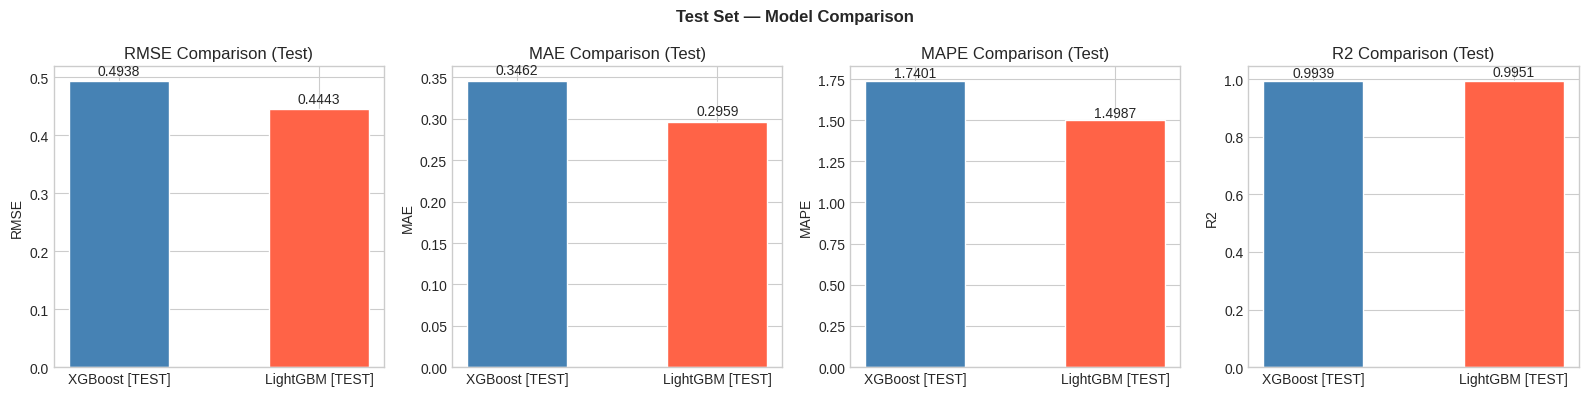

  Saved -> reports/model_comparison_test.png


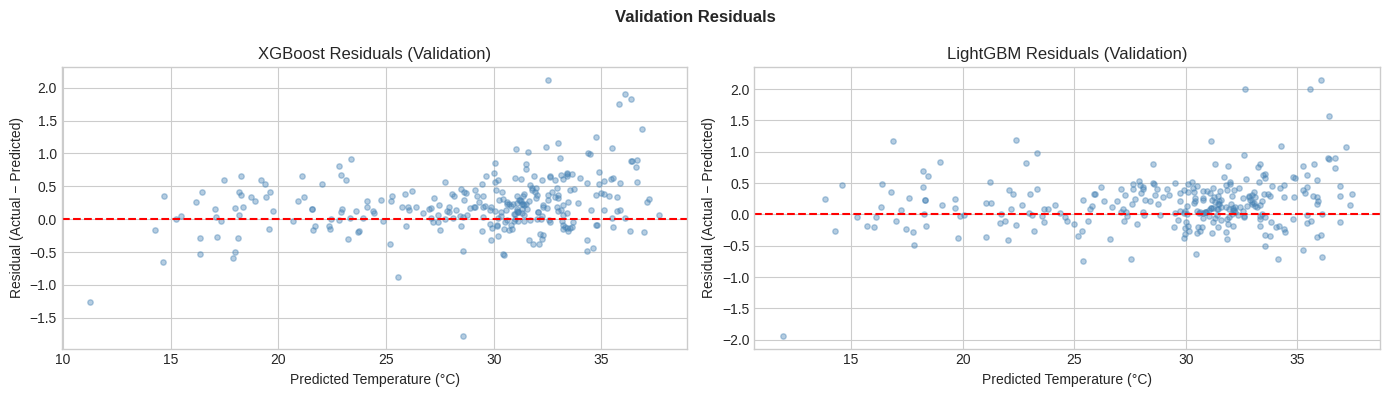

  Saved -> reports/residuals_val.png


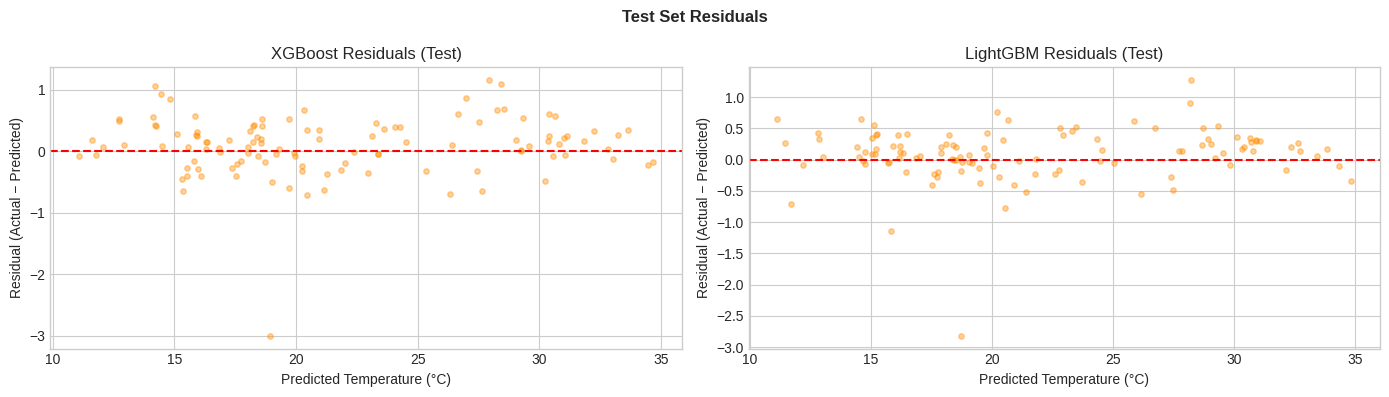

  Saved -> reports/residuals_test.png

  Computing SHAP values (XGBoost) on Validation…


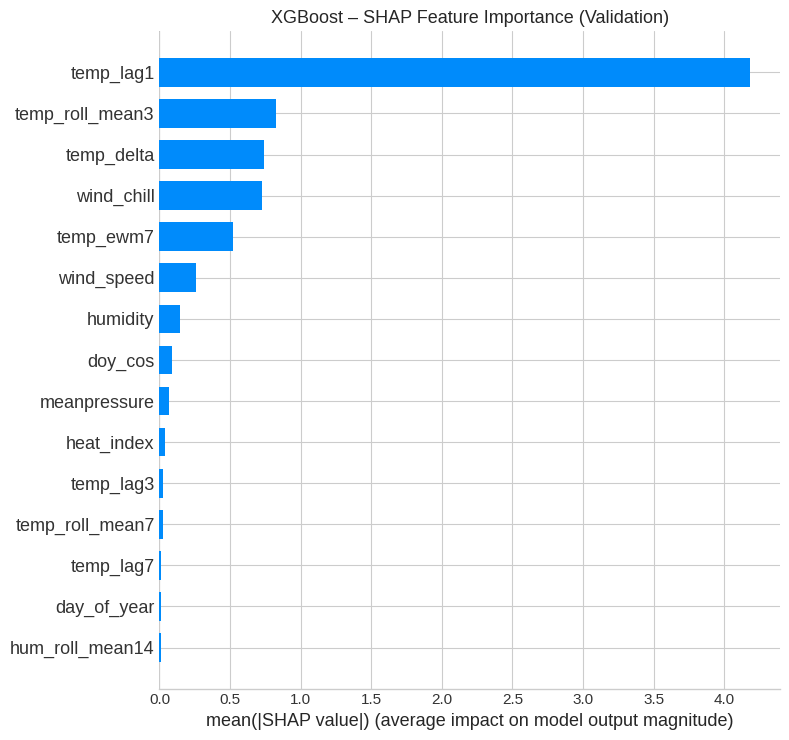

  Saved -> reports/shap_bar.png


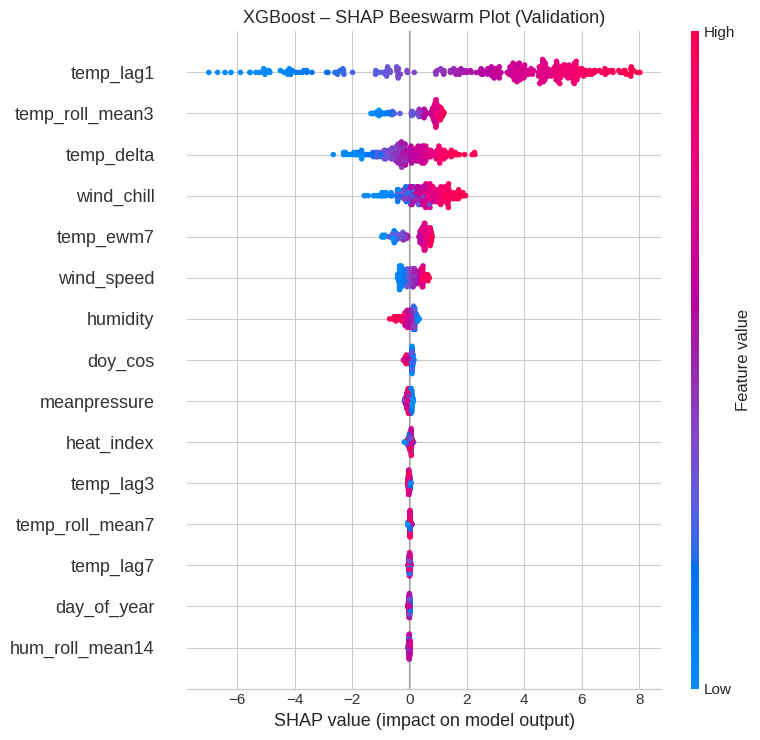

  Saved -> reports/shap_beeswarm.png

  Computing SHAP values (XGBoost) on Test Set…


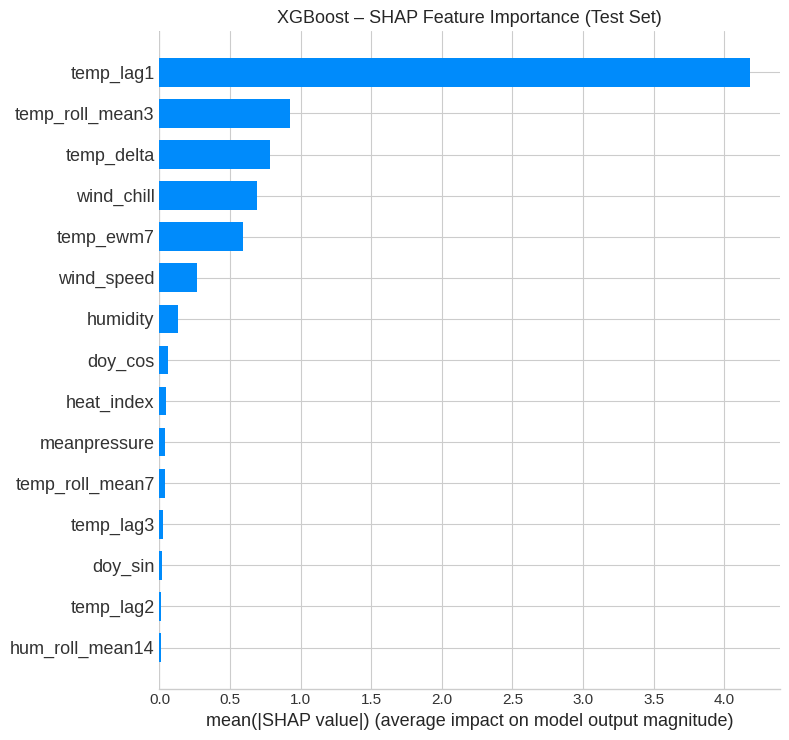

  Saved -> reports/shap_bar_test.png


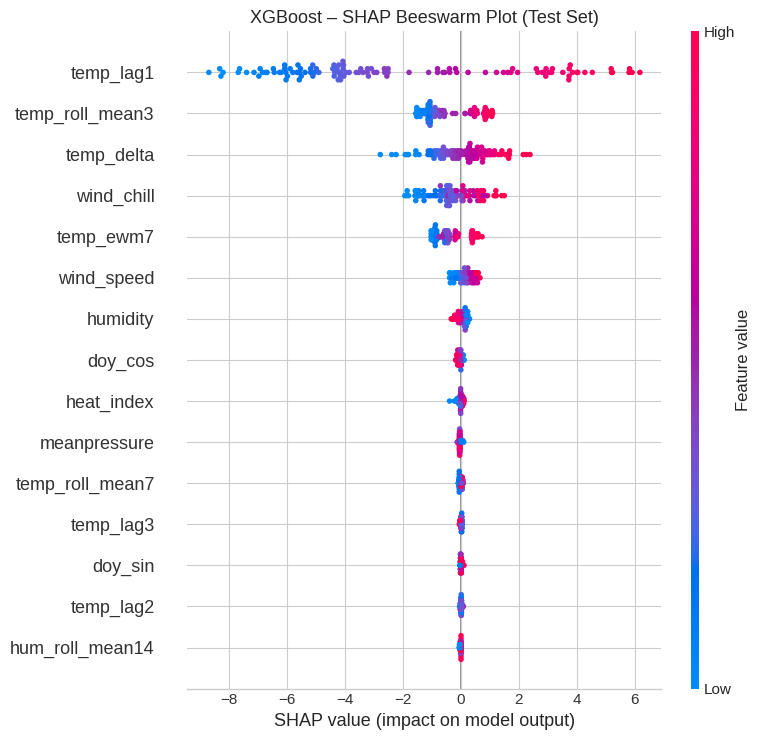

  Saved -> reports/shap_beeswarm_test.png

Ensemble weights – XGBoost: 0.485, LightGBM: 0.515
  (weights derived from validation RMSE — test set remains unseen)
────────────────────────────────────────
Model : Ensemble (Weighted Avg)
RMSE  : 0.4472 °C
MAE   : 0.3095 °C
MAPE  : 1.10%
R²    : 0.9938
────────────────────────────────────────
────────────────────────────────────────
Model : Ensemble (Weighted Avg) [TEST]
RMSE  : 0.4451 °C
MAE   : 0.2984 °C
MAPE  : 1.50%
R²    : 0.9951
────────────────────────────────────────
  ↑ Ensemble evaluated on HELD-OUT TEST SET

=== FINAL MODEL COMPARISON (Validation) ===
                  model     RMSE      MAE     MAPE       R2
                XGBoost 0.482723 0.347053 1.218357 0.992746
               LightGBM 0.454529 0.320686 1.150712 0.993569
Ensemble (Weighted Avg) 0.447168 0.309454 1.095101 0.993775

=== FINAL MODEL COMPARISON (Test Set) ===
                         model     RMSE      MAE     MAPE       R2
                XGBoost [TEST] 0.49

<Figure size 640x480 with 0 Axes>

In [7]:
# STEP 7: Model Training & Evaluation (pipeline-aware)
import os
os.chdir('/content/Ensemble-weather-prediction')

print(f'Training models for {pipeline_name} pipeline...')
print(f'Script: {train_script}\n')

%run $train_script

print(f'\n  Model Training complete! (Pipeline: {pipeline_name})')

# Remind user how to run the other pipeline
other = 'advanced' if RUN_BASELINE else 'baseline'
print(f'\n  Tip: Go back to the Pipeline Toggle and set RUN_BASELINE={not RUN_BASELINE}')
print(f'       to also run the {other} pipeline and compare results!')


## OPTIONAL — Compare Baseline vs Advanced Pipeline Results
> After running both pipelines, use this cell to print a side-by-side metric comparison.
> (Run the **toggle cell** with `RUN_BASELINE=True` then `False`, executing Steps 6–7 each time.)

In [12]:
# OPTIONAL: Side-by-side comparison of both pipelines
# Only works if you have run BOTH pipelines (baseline AND advanced).
import os, joblib
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

os.chdir('/content/Ensemble-weather-prediction')

results = []

for label, model_path, data_path, meta_path in [
    ('Baseline  (3 features)',  'models/xgb_baseline.pkl',    'data/processed/train_baseline.csv', 'models/baseline_feature_meta.pkl'),
    ('Advanced (40+ features)', 'models/xgboost_model.pkl',   'data/processed/train_features.csv', 'models/feature_meta.pkl'),
]:
    if not (os.path.exists(model_path) and os.path.exists(data_path)):
        print(f'  Skipping {label} — files not found yet')
        continue
    model    = joblib.load(model_path)
    meta     = joblib.load(meta_path)
    df       = pd.read_csv(data_path)
    split    = int(len(df) * 0.8)
    X_val    = df[meta['features']].iloc[split:].fillna(df[meta['features']].median())
    y_val    = df[meta['target']].iloc[split:]
    pred     = model.predict(X_val)
    rmse     = np.sqrt(mean_squared_error(y_val, pred))
    mae      = mean_absolute_error(y_val, pred)
    r2       = 1 - np.sum((y_val - pred)**2) / np.sum((y_val - y_val.mean())**2)
    results.append({'Pipeline': label, 'Features': len(meta['features']), 'RMSE': round(rmse,4), 'MAE': round(mae,4), 'R2': round(r2,4)})

if results:
    cmp = pd.DataFrame(results)
    print('\n' + '=' * 60)
    print('  PIPELINE COMPARISON — XGBoost')
    print('=' * 60)
    print(cmp.to_string(index=False))
    if len(results) == 2:
        rmse_imp = ((results[0]['RMSE'] - results[1]['RMSE']) / results[0]['RMSE']) * 100
        r2_imp   = results[1]['R2'] - results[0]['R2']
        print(f'\n  Feature engineering reduced RMSE by   {rmse_imp:.1f}%')
        print(f'  Feature engineering improved R² by    {r2_imp:+.4f}')
    print('=' * 60)


  Skipping Baseline  (3 features) — files not found yet

  PIPELINE COMPARISON — XGBoost
               Pipeline  Features   RMSE    MAE     R2
Advanced (40+ features)        43 0.4827 0.3471 0.9927


## STEP 8 — LSTM Model
> Trains a **Bidirectional LSTM + Multi-Head Attention** model.
>
> - Reads from `data/raw/` and builds its own feature engineering
> - Architecture: BiLSTM(256) → BiLSTM(128) + Residual → MHA → LSTM(64) → Dense head
> - Lookback window: 30 days
> - Saves: `models/lstm_model.keras`  and  `data/predictions/lstm.csv`
>
> **Runtime: ~5–15 minutes depending on GPU availability.**
> Enable GPU in Colab: Runtime → Change runtime type → T4 GPU

In [11]:
# STEP 8: LSTM Model
import os
os.chdir('/content/Ensemble-weather-prediction')

if RUN_LSTM:
    print('Running LSTM pipeline...')
    %run notebooks/05_lstm_model.py
    print('\n  LSTM complete! → data/predictions/lstm.csv')
else:
    print('RUN_LSTM = False — skipping. Set RUN_LSTM = True in the toggle cell to enable.')


Running LSTM pipeline...
  LSTM MODEL — Bidirectional LSTM + MultiHeadAttention
✅ Saved lstm_scaler.pkl
Epoch 1/250
153/153 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 0.0092 - mae: 0.1030 - val_loss: 0.0080 - val_mae: 0.1115
Epoch 2/250
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0053 - mae: 0.0823 - val_loss: 0.0118 - val_mae: 0.1295
Epoch 3/250
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0045 - mae: 0.0749 - val_loss: 0.0048 - val_mae: 0.0804
Epoch 4/250
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0032 - mae: 0.0634 - val_loss: 0.0092 - val_mae: 0.1187
Epoch 5/250
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0038 - mae: 0.0687 - val_loss: 0.0019 - val_mae: 0.0496
Epoch 6/250
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0026 - mae: 0.0551 - val_loss: 0.0029 - val_mae: 0.0591
Epoch 7/250
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0023 - mae: 0.0532 - val_loss: 0.0036 - val_mae: 0.0716
Epoch 8/250
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step -

In [13]:
# 🔥 QUICK FIX — recreate and save scaler without retraining model

import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import joblib
import os

TRAIN_PATH = 'data/raw/Train.csv'
DATE_COL = 'date'
TARGET_COL = 'meantemp'

# Load data
train_df = pd.read_csv(TRAIN_PATH, parse_dates=[DATE_COL])
train_df = train_df.sort_values(DATE_COL).reset_index(drop=True)

# SAME feature engineering (minimal required)
def engineer_features(df):
    df = df.copy()
    df = df.ffill().fillna(0)
    return df

train_df = engineer_features(train_df)

# Prepare features
feature_cols = [c for c in train_df.columns if c != DATE_COL]
feature_cols = [TARGET_COL] + [c for c in feature_cols if c != TARGET_COL]

# Fit scaler
scaler = MinMaxScaler()
scaler.fit(train_df[feature_cols])

# Save scaler
os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/lstm_scaler.pkl')

print("✅ FIXED: lstm_scaler.pkl created successfully")

✅ FIXED: lstm_scaler.pkl created successfully


## STEP 9 — AR / ARIMA / SARIMA Models
> Trains three statistical time-series models using **walk-forward evaluation**.
>
> - AR: AutoRegressive model, lag scan over p = [1,2,3,5,7]
> - ARIMA(p,1,q): differenced AR+MA, order scan
> - SARIMA(p,1,q)(P,1,Q,7): adds weekly seasonality
> - Saves: `models/ar_model.pkl`, `arima_model.pkl`, `sarima_model.pkl`
>   and `data/predictions/arima.csv`, `sarima.csv`
>
> **Runtime: ~10–20 minutes** (walk-forward refits model for each of 114 test rows).

In [14]:
# STEP 9: AR / ARIMA / SARIMA Models
import os
os.chdir('/content/Ensemble-weather-prediction')

if RUN_ARIMA:
    print('Running AR/ARIMA/SARIMA pipeline...')
    %run notebooks/05_arima_model.py
    print('\n  AR/ARIMA/SARIMA complete! → data/predictions/arima.csv, sarima.csv')
else:
    print('RUN_ARIMA = False — skipping. Set RUN_ARIMA = True in the toggle cell to enable.')


Running AR/ARIMA/SARIMA pipeline...
  AR / ARIMA / SARIMA — Statistical Time-Series Models

  Train : 1462 rows  2013-01-01 -> 2017-01-01
  Test  : 114 rows   2017-01-01 -> 2017-04-24

  Train temperature: mean=25.50°C  std=7.35°C
  Test  temperature: mean=21.71°C   std=6.33°C

  AR WALK-FORWARD — scanning lags p = [1,2,3,5,7]
  Model             RMSE       MAE      MAPE        R²
  AR(p=1)          1.7468    1.3413     6.84%    0.9239
  AR(p=2)          1.7334    1.3382     6.80%    0.9251
  AR(p=3)          1.7348    1.3293     6.74%    0.9249
  AR(p=5)          1.7545    1.3839     6.98%    0.9232
  AR(p=7)          1.7489    1.3951     7.01%    0.9237

  -> Best AR lag = 2  (RMSE = 1.7334)

  ARIMA WALK-FORWARD — scanning (p,1,q) orders
  Model                     RMSE       MAE      MAPE        R²
  ARIMA(1,1,0)             1.7529    1.3621     6.92%    0.9234
  ARIMA(1,1,1)             1.7421    1.3779     6.88%    0.9243
  ARIMA(2,1,1)             1.7441    1.3794     6.89%    0

## STEP 10 — Ensemble: Combine All Models
> Merges all prediction files and builds a **weighted average ensemble**.
>
> Default weights: `XGB=0.25, LGB=0.25, LSTM=0.20, ARIMA=0.15, SARIMA=0.15`
>
> Missing models are automatically excluded and weights renormalised.
> You can change weights in `notebooks/06_ensemble.py` → `WEIGHTS` dict.
>
> Saves: `data/predictions/ensemble_final.csv` and comparison plots in `reports/`.

In [ ]:
# STEP 10: Ensemble
import os
os.chdir('/content/Ensemble-weather-prediction')

if RUN_ENSEMBLE:
    print('Running ensemble pipeline...')
    %run notebooks/06_ensemble.py
    print('\n  Ensemble complete! → data/predictions/ensemble_final.csv')
else:
    print('RUN_ENSEMBLE = False — skipping.')


Running ensemble pipeline...
  ENSEMBLE — Combining All Model Predictions

  Loading prediction files from 'data/predictions/'...
  ──────────────────────────────────────────────────
  OK   xgb      : 114 rows  2017-01-01 → 2017-04-24  pred_range=[11.1, 34.7]°C
  OK   lgb      : 114 rows  2017-01-01 → 2017-04-24  pred_range=[11.1, 34.8]°C
  OK   lstm     : 114 rows  2017-01-01 → 2017-04-24  pred_range=[11.8, 33.0]°C
  OK   arima    : 114 rows  2017-01-01 → 2017-04-24  pred_range=[11.4, 33.8]°C
  OK   sarima   : 114 rows  2017-01-01 → 2017-04-24  pred_range=[11.5, 33.7]°C

  Active models and adjusted weights:
    xgb       0.250  ██████████
    lgb       0.250  ██████████
    lstm      0.200  ████████
    arima     0.150  ██████
    sarima    0.150  ██████

  Merging predictions on 'date' (inner join)...
  Merged shape : (114, 8)
  Date range   : 2017-01-01 → 2017-04-24
  Rows dropped : 0

  Ensemble prediction range : [11.74, 33.95]°C

  INDIVIDUAL MODEL METRICS
  ────────────────────

## OPTIONAL — Quick Results Summary
> Prints a consolidated table of every available model's metrics.
> Run after Step 10 (or after any subset of models you've trained).

In [ ]:
# OPTIONAL: Print final results summary from ensemble_final.csv
import os, pandas as pd, numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

os.chdir('/content/Ensemble-weather-prediction')

final_path = 'data/predictions/ensemble_final.csv'
if not os.path.exists(final_path):
    print('ensemble_final.csv not found — run Step 10 first.')
else:
    df = pd.read_csv(final_path, parse_dates=['date'])
    actual = df['actual'].values
    pred_cols = [c for c in df.columns if c.startswith('pred_') or c == 'prediction_ensemble']
    rows = []
    for col in pred_cols:
        p    = df[col].values
        rmse = round(np.sqrt(mean_squared_error(actual, p)), 4)
        mae  = round(mean_absolute_error(actual, p), 4)
        r2   = round(r2_score(actual, p), 4)
        rows.append({'Model': col.replace('pred_','').replace('_',' ').upper(),
                     'RMSE': rmse, 'MAE': mae, 'R2': r2})
    results = pd.DataFrame(rows).sort_values('RMSE')
    print('\n' + '='*55)
    print('  FINAL MODEL COMPARISON')
    print('='*55)
    print(results.to_string(index=False))
    best = results.iloc[0]
    print(f'\n  Best model: {best.Model}  RMSE={best.RMSE}  R²={best.R2}')
    print('='*55)



  FINAL MODEL COMPARISON
              Model   RMSE    MAE     R2
                LGB 0.4443 0.2959 0.9951
                XGB 0.4938 0.3462 0.9939
PREDICTION ENSEMBLE 0.9251 0.7643 0.9787
             SARIMA 1.7268 1.3622 0.9256
              ARIMA 1.7421 1.3779 0.9243
               LSTM 1.8910 1.6021 0.9108

  Best model: LGB  RMSE=0.4443  R²=0.9951


## STEP 11 — Push Models Back to GitHub
> Replace `YOUR_PAT` with your GitHub Personal Access Token.
> Get it from: GitHub → Settings → Developer Settings → Personal Access Tokens → Generate new token (check `repo` scope)


## STEP 12 — Launch Streamlit App
> Click the printed ngrok URL to open your app in a new tab.


In [ ]:
!ls models/

arima_model.pkl       feature_meta.pkl	  lstm_model.keras  xgboost_model.pkl
ar_model.pkl	      lightgbm_model.pkl  lstm_scaler.pkl
ensemble_weights.pkl  lstm_best.keras	  sarima_model.pkl
